<a href="https://colab.research.google.com/github/tsilva/aiml-notebooks/blob/main/notebooks/wip-hf-sentiment-analysis-bert-imdb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HF Transformers - Sentiment Analysis - IMDB 🎬✨

In this notebook, we'll finetune a pretrained language model (e.g., [BERT](https://huggingface.co/google-bert/bert-base-uncased)) 📚 on the [stanfordnlp/imdb](https://huggingface.co/datasets/stanfordnlp/imdb) dataset 🎬 using [Hugging Face Transformers](https://huggingface.co/docs/transformers/index) 🚀.

## Setup ⚙️

First, let's install the necessary packages: 📦✨

In [1]:
!pip install transformers datasets evaluate accelerate huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 484.9/484.9 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Define the seed for reproducibility in this notebook: 🌱📓

In [ ]:
SEED = 42

Ensure you are logged in to Hugging Face (HF_TOKEN in secrets) 🔑✨:

In [4]:
from huggingface_hub import whoami
whoami()

{'type': 'user',
 'id': '6380e3a9a12ba48637ba3385',
 'name': 'tsilva',
 'fullname': 'Tiago Silva',
 'isPro': False,
 'avatarUrl': 'https://cdn-avatars.huggingface.co/v1/production/uploads/6380e3a9a12ba48637ba3385/wQncbCpBfGTW4vgyPe9Uu.jpeg',
 'orgs': [],
 'auth': {'type': 'access_token',
  'accessToken': {'displayName': 'test',
   'role': 'fineGrained',
   'createdAt': '2025-02-18T18:26:17.516Z',
   'fineGrained': {'canReadGatedRepos': True,
    'global': ['inference.serverless.write'],
    'scoped': [{'entity': {'_id': '6380e3a9a12ba48637ba3385',
       'type': 'user',
       'name': 'tsilva'},
      'permissions': ['repo.content.read',
       'repo.write',
       'collection.read',
       'collection.write']}]}}}}

Now, let's retrieve the identifier of the best training device (CPU 🖥️ vs. GPU 🎮):

In [5]:
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE_SUPPORTS_BF16 = torch.cuda.is_bf16_supported() if torch.cuda.is_available() else False
print(f"Using device: {DEVICE}")

Using device: cuda


Let's select a base model to finetune. 🛠️ This process leverages the knowledge gained during pretraining, requiring significantly less training time ⏳ than training a model from scratch. We'll load the model later in the notebook. 📓

In [6]:
MODEL_ID = "distilbert/distilbert-base-uncased" # 92% test set accuracy
#MODEL_ID = "bert-base-uncased" # 92% test set accuracy
#MODEL_ID = "bert-base-cased" # 92% test set accuracy
#MODEL_ID = "openai-community/gpt2" # 94% test set accuracy, starting accuracy is 50% but this is most likely due to the new classificaiton head, the better performance we get on GPT2 is probably related to the model already being able to do sentiment classification through text generation

Let's define the identifier for the [IMDB dataset](https://huggingface.co/datasets/stanfordnlp/imdb) 🎬, which pairs reviews 📝 with binary sentiment classifications (positive 👍 or negative 👎):

In [7]:
DATASET_ID = "stanfordnlp/imdb"

Create a model card 📄 and upload it to the hub 🌐:

In [45]:
from huggingface_hub import ModelCard, ModelCardData

# Create model card
# TODO: softcode this
HF_MODEL_ID = f"distilbert_imdb_finetune" #"{MODEL_ID}_{DATASET_ID}_finetune"
model_card = ModelCard.from_template(
    card_data=ModelCardData(
        language="en",
        license="mit",
        tags=["sentiment-analysis", MODEL_ID],
        library_name="transformers",
        model_name=HF_MODEL_ID,
        datasets=[DATASET_ID],
        metrics=["accuracy"],
    ),
    model_description=f"This model fine-tunes {MODEL_ID} on the {DATASET_ID} dataset.",
)

# Push model card to hub
model_card.push_to_hub(f"tsilva/{HF_MODEL_ID}")

RepositoryNotFoundError: 404 Client Error. (Request ID: Root=1-67b4d52a-1a74febe4aed788450afe995;825d5896-2e91-4bf0-966d-4e07de3f5c4a)

Repository Not Found for url: https://huggingface.co/api/models/tsilva/distilbert_imdb_finetune/preupload/main.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated.
Note: Creating a commit assumes that the repo already exists on the Huggingface Hub. Please use `create_repo` if it's not the case.

## Prepare Dataset 📊✨

Load the dataset 📊:

In [8]:
from datasets import load_dataset

raw_dataset = load_dataset(DATASET_ID)
raw_dataset

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

unsupervised-00000-of-00001.parquet:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

The dataset includes a `train` split with 25k samples 📊, a `test` split with 25k samples 🧪, and an `unsupervised` split with 50k entries 📈. Its purpose is unclear 🤔, so let's inspect it 🔍:

In [9]:
raw_dataset["unsupervised"][0]

{'text': 'This is just a precious little diamond. The play, the script are excellent. I cant compare this movie with anything else, maybe except the movie "Leon" wonderfully played by Jean Reno and Natalie Portman. But... What can I say about this one? This is the best movie Anne Parillaud has ever played in (See please "Frankie Starlight", she\'s speaking English there) to see what I mean. The story of young punk girl Nikita, taken into the depraved world of the secret government forces has been exceptionally over used by Americans. Never mind the "Point of no return" and especially the "La femme Nikita" TV series. They cannot compare the original believe me! Trash these videos. Buy this one, do not rent it, BUY it. BTW beware of the subtitles of the LA company which "translate" the US release. What a disgrace! If you cant understand French, get a dubbed version. But you\'ll regret later :)',
 'label': -1}

This is likely an unlabeled split, but let's confirm that the entire split has a label of `-1` 🔍:

In [10]:
list(set([x["label"] for x in raw_dataset["unsupervised"]]))

[-1]

`unsupervised` indicates an unsupervised split without labels. While it won't aid sentiment analysis, it may be useful for generating similar reviews ✍️ (text generation task).

Let's explore the dataset features: 📊✨

In [11]:
raw_dataset["train"].features

{'text': Value(dtype='string', id=None),
 'label': ClassLabel(names=['neg', 'pos'], id=None)}

Inspect samples from the `train` split: 🔍📊

In [12]:
raw_dataset["train"][:5]["text"]

['I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, e

Check the variability of text lengths 📏📊:

In [13]:
raw_dataset = raw_dataset.map(
    lambda batch: {"text_length": [len(text.split()) for text in batch["text"]]},
    batched=True
)
raw_dataset

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'text_length'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label', 'text_length'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label', 'text_length'],
        num_rows: 50000
    })
})

Let's plot the distribution of text lengths 📊✍️.

({'min': 10, 'max': 2470, 'avg': 233.7872},
 <module 'matplotlib.pyplot' from '/usr/local/lib/python3.11/dist-packages/matplotlib/pyplot.py'>)

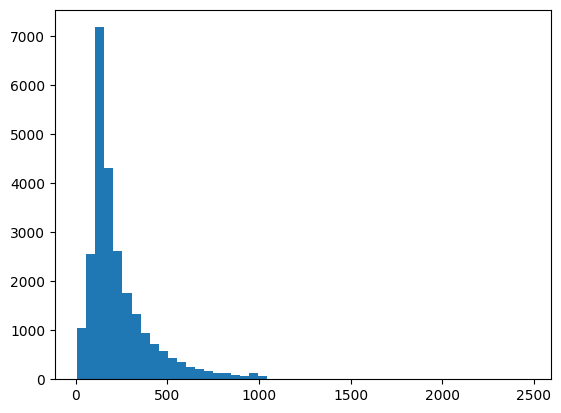

In [14]:
import matplotlib.pyplot as plt

# Plot histogram
text_lengths = [x["text_length"] for x in raw_dataset["train"]]
plt.hist(text_lengths, bins=50)

# Print stats and show histogram plot
dict(
    min=min(text_lengths),
    max=max(text_lengths),
    avg=sum(text_lengths) / len(text_lengths)
), plt

Let's extract a validation set from the training data 📊. We want to keep the test set untouched until the end 🚫 to avoid influencing our training 🏋️‍♂️.

In [15]:
split_dataset = raw_dataset["train"].train_test_split(test_size=0.1, seed=42) # Extract 10%
split_dataset["validation"] = split_dataset.pop("test")
split_dataset["test"] = raw_dataset["test"]
split_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'text_length'],
        num_rows: 22500
    })
    validation: Dataset({
        features: ['text', 'label', 'text_length'],
        num_rows: 2500
    })
    test: Dataset({
        features: ['text', 'label', 'text_length'],
        num_rows: 25000
    })
})

Now, let's tokenize the dataset: 🗂️✨

In [16]:
import multiprocessing
from transformers import AutoTokenizer

# Load the tokenizer for our model
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

# Tokenize the dataset
tokenized_dataset = split_dataset.map(
    lambda batch: tokenizer(batch["text"], truncation=True), # Define how samples are tokenized (truncate them to max model sequence length)
    batched=True, # Process in batches to minimize task overhead (eg: function calling, memory allocation, etc.)
    num_proc=multiprocessing.cpu_count(), # Tokenize in parallel using all available cores
    remove_columns=["text", "text_length"] # Drop columns we won't need, to make the dataset smaller (less memory usage)
)
tokenized_dataset

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map (num_proc=12):   0%|          | 0/22500 [00:00<?, ? examples/s]

Map (num_proc=12):   0%|          | 0/2500 [00:00<?, ? examples/s]

Map (num_proc=12):   0%|          | 0/25000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 22500
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 2500
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 25000
    })
})

Let's instantiate a data collator for our dataset. 📊 Instead of padding the tokenized text to the maximum sequence length of the entire dataset, which is large and would add irrelevant tokens, ❌ we can use a DataCollatorWithPadding object. 🛠️ This will dynamically pad batches based on the maximum sequence length within each batch. 📏

In [17]:
from transformers import AutoModelForSequenceClassification, DataCollatorWithPadding

# Instantiate the data collator (it will be responsible for padding
# sequence batches before running them through models)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

## Finetune the model 🎯✨

Load the model: 📦🔄

In [18]:
from transformers import AutoModelForSequenceClassification

# Load the model (architecture + weights) and adapt it for sequence classification
# (its head is swapped with a classification head for this task)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID)

# In case the model has no padding token,
# add one (eg: `openai-community/gpt2` doesn't have one)
if tokenizer.pad_token_id is None:
   tokenizer.pad_token_id = tokenizer.eos_token_id
   model.config.pad_token_id = tokenizer.pad_token_id

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


If you're using an uncased model, you might wonder how it handles cased sequences (e.g., whether to lowercase the dataset). 🤔 Run the code below to verify that the tokenizer treats the string as lowercase, eliminating the need for preprocessing: 🛠️

In [19]:
tokenizer.convert_ids_to_tokens(tokenizer("This is a Test!")["input_ids"])

['[CLS]', 'this', 'is', 'a', 'test', '!', '[SEP]']

Set up the training run: 🏃‍♂️💪

In [34]:
import torch
import numpy as np
import evaluate
from transformers import Trainer
from transformers import TrainingArguments
from transformers import EarlyStoppingCallback

def compute_metrics(eval_pred):
    metric = evaluate.load("accuracy")
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    metrics = metric.compute(predictions=predictions, references=labels)
    return metrics

training_args = TrainingArguments(
    # Where to output the model to
    output_dir=HF_MODEL_ID,
    # Identifier for model in HF hub
    hub_model_id=HF_MODEL_ID,
    # Ensure seed consistency in training arguments
    seed=SEED,
    # When train() is run again, restore from previous checkpoint
    resume_from_checkpoint=True,
    # Train for N epochs
    num_train_epochs=10,
    # Number of training samples sent to the GPU per batch.
    # Larger batches:
    #   - Increase memory usage (may cause OOM errors if too large).
    #   - Provide more stable gradients (less variance), leading to smoother updates.
    #   - Can improve training speed (fewer updates per epoch).
    #   - May lead to worse generalization (risk of converging to sharp local minima).
    # Smaller batches:
    #   - Use less memory, allowing training on limited hardware.
    #   - Introduce more gradient noise, which can help escape local minima.
    #   - May improve generalization by avoiding sharp, overfit solutions.
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    # Number of steps to accumulate gradients before performing an optimization step.
    # - Useful when VRAM is limited and larger batch sizes don't fit in memory.
    # - Effectively simulates a larger batch by accumulating gradients over multiple smaller batches.
    # - Setting this >1 means fewer optimization steps per epoch, but similar gradient updates as using a larger batch.
    # - **Cons:**
    #   - **Slower updates**: Since weights are updated less frequently, training may take longer.
    #   - **Training instability**: Large accumulated gradients can lead to instability if learning rate is not adjusted.
    #   - **Requires learning rate tuning**: Since it changes the effective batch size, the learning rate should be scaled accordingly.
    #   - **Higher memory usage for gradients**: Even though the batch size per step is small, stored gradients take up memory.
    gradient_accumulation_steps=1,
    # Use BF16 if available:
    # - higher number range than FP16
    # - less precision than FP16
    # - less memory usage than FP16
    fp16=not DEVICE_SUPPORTS_BF16,
    bf16=DEVICE_SUPPORTS_BF16,
    # Perform evaluation every training epoch by
    # calling `compute_metrics` on the `eval_dataset` (see below in `Trainer` instantiation)
    eval_strategy="epoch",
    # Save best model every training epoch
    save_strategy="epoch",
    # Consider best model the one with best validation loss
    # (checkpointing on best accuracy may save a overfitted
    # model that has great accuracy on validation set but not
    # in test set or real world)
    metric_for_best_model="eval_loss",
    # Lower validation loss is better (default is greater is better)
    greater_is_better=False,
    # When training ends load weights of best model found during training
    load_best_model_at_end=True,
    # Disable WandB logging
    report_to="none",
    logging_first_step=True
)

trainer = Trainer(
    model, # The model to be trained
    training_args, # The training settings
    train_dataset=tokenized_dataset["train"], # The dataset to train the model on
    eval_dataset=tokenized_dataset["validation"], # The dataset to evaluate the model on
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)], # Stop if validation loss doesn't improve for 3 epochs
    processing_class=tokenizer, # Tokenizer to pair with specified model
    data_collator=data_collator, # The data collator to run through batch before using it (eg: pad sequences to max sequence length in that batch)
    compute_metrics=compute_metrics  # Function that calculates the evaluation metrics
)
trainer

SyntaxError: invalid syntax. Perhaps you forgot a comma? (<ipython-input-34-b9fa636e44ce>, line 18)

First, let's evaluate the model 📊 to establish our baseline:

In [21]:
trainer.evaluate()

{'eval_loss': 0.7044187784194946,
 'eval_model_preparation_time': 0.0018,
 'eval_accuracy': 0.4972,
 'eval_runtime': 5.541,
 'eval_samples_per_second': 451.179,
 'eval_steps_per_second': 56.488}

Without finetuning, the model is about 50% accurate 🎯, indicating random guesses 🤔. Now, let's train the model 📚:

In [31]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.258000,0.247541,0.922000


TrainOutput(global_step=2813, training_loss=0.30796911603735727, metrics={'train_runtime': 93.3945, 'train_samples_per_second': 240.914, 'train_steps_per_second': 30.12, 'total_flos': 2810024718280416.0, 'train_loss': 0.30796911603735727, 'epoch': 1.0})

Evaluation accuracy improved significantly in just a few epochs. 📈✨

To push the trained model to the Hugging Face hub, uncomment and run the cell below: 🐻💻✨

In [ ]:
#trainer.push_to_hub()

## Evaluate Model 📊🔍

Running `evaluate()` will assess the dataset specified in `eval_dataset` for the `Trainer` 🏃‍♂️📊:

In [23]:
trainer.evaluate()

{'eval_loss': 0.7044187784194946,
 'eval_model_preparation_time': 0.0018,
 'eval_accuracy': 0.4972,
 'eval_runtime': 4.8415,
 'eval_samples_per_second': 516.371,
 'eval_steps_per_second': 64.65}

This is equivalent to directly specifying the dataset 📊:

In [24]:
trainer.evaluate(tokenized_dataset["validation"])

{'eval_loss': 0.7044187784194946,
 'eval_model_preparation_time': 0.0018,
 'eval_accuracy': 0.4972,
 'eval_runtime': 4.8206,
 'eval_samples_per_second': 518.61,
 'eval_steps_per_second': 64.93}

The final evaluation post-training will be on the test dataset 📊, which was not used during training. 🏋️‍♂️

In [25]:
trainer.evaluate(tokenized_dataset["test"])

{'eval_loss': 0.70362389087677,
 'eval_model_preparation_time': 0.0018,
 'eval_accuracy': 0.5,
 'eval_runtime': 37.9003,
 'eval_samples_per_second': 659.625,
 'eval_steps_per_second': 82.453}

Let's dump some misclassified examples. 📊 First, we need the predictions for the test set: 🧪

In [26]:
predictions = trainer.predict(tokenized_dataset["test"])
logits = predictions.predictions
predicted_labels = np.argmax(logits, axis=-1)
predicted_labels

array([0, 0, 0, ..., 0, 0, 0])

Identify the mislabeled samples: 🕵️‍♂️🔍

In [27]:
true_labels = predictions.label_ids
misclassified_indices = np.where(predicted_labels != true_labels)[0]
len(misclassified_indices)

12500

Let's create a table of mismatches: 📊✨

In [28]:
import pandas as pd
import numpy as np
from IPython.display import Markdown

# Sample N texts and labels
label_names = raw_dataset["train"].features["label"].names
sample_indices = np.random.choice(misclassified_indices, size=5, replace=False)
sample_texts = raw_dataset["test"].select(sample_indices)["text"]
sample_true_labels = [label_names[x] for x in np.array(true_labels)[sample_indices].tolist()]
sample_predicted_labels = [label_names[x] for x in np.array(predicted_labels)[sample_indices].tolist()]

# Identify which samples were truncated when tokenized
# (could truncation be affecting classification?)
input_ids = tokenized_dataset["test"].select(sample_indices)["input_ids"]
text_lengths = [len(x) for x in input_ids]
sample_truncated = [x > tokenizer.model_max_length for x in text_lengths]

# Create dataframe
df = pd.DataFrame({
    "Index": sample_indices,
    "Text": sample_texts,
    "True Label": sample_true_labels,
    "Predicted Label": sample_predicted_labels,
    "Truncated" : sample_truncated
})

# Render as markdown
markdown_table = df.to_markdown(index=False)
Markdown(markdown_table)

|   Index | Text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         | True Label   | Predicted Label   | Truncated   |
|--------:|:---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:-------------|:------------------|:------------|
|   14266 | The movie was certainly true to the real life story on which it was based. It was hard for me to find newspaper articles about the actual facts, but when I located them, I could see that truth, in this case, was stranger than fiction. Judith Light was frighteningly evil in her role as the mother in this movie, so much so that it was difficult to separate her from the role, the mark I think of an excellent performance. Rick Schroder was appropriately clueless as her son who also defended her in court, an example of how hard it can be in some circumstances for a child to accept the actions of a parent, no matter how criminal they may be. One can find fault with the movie, but not with its treatment of the reality on which it was based.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      | pos          | neg               | False       |
|   24419 | Ex-reporter Jacob Asch (Eric Roberts) is hired by an acquaintance (Raymond J. Barry) to find his ex-wife and son. Asch heads to Palm Springs and quickly locates the ex Laine (Beverly D'Angelo) with someone he believes to be the son (a young Johnny Depp). But things turn out to be a bit more complicated as Asch discovers former white trash Laine has definitely married up in the form of millionaire Simon Fleischer (Dan Hedaya) and her first son is nowhere to be seen.<br /><br />Director/writer Matthew Chapman is channeling BODY HEAT here and this mid-80s neo-noir is watchable enough thanks to an all-star cast and nice locations. D'Angelo was still looking good around this time, so she makes for a good femme fatale and isn't afraid to show some skin. However, the mystery isn't very compelling in the end. Co-starring Dennis Lipscomb, Emily Longstreth and Henry Gibson. Chapman made several thrillers in the 80s, but his "biggest" career achievement was co-authoring the screenplay for the infamous COLOR OF NIGHT.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                | pos          | neg               | False       |
|   21409 | This movie is basically a spoof on Hitchcock's Strangers on a train, which i thought was overrated anyway. The plot has Danny Devito going to see Strangers and then thinking Billy Crystal wants them to swap murders, For Crystal to murder his mother and Devito to murder his wife. Both Devito and Crystal are great and so is Devito's mother. This is Devito's directorial debut and it's better than the war of the roses.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           | pos          | neg               | False       |
|   17463 | I never saw any of The League's work until early last year - although when channel hopping one night I caught the end of one the series three episodes. But last winter I fell in love with the show and its dark, eccentric and sometimes downright sinister characters. So when I learnt they had made a film in which the show's lovable creators met their own characters, I couldn't order the DVD fast enough and near on tore it from my postman's hands when he delivered it. I was so excited to see what the Gents had done and how they'd done it.<br /><br />And it was excellent! From the beginning where Jeremy (Michael Sheen) is terrorised by Edward, Tubbs and Papa (Dyson, why didn't you play yourself? He's perfectly capable as viewers of the infamous Highgate House of Horrors know!), to Bernice berating yet another one of her flock, to Geoff, Herr Lipp and Hilary discovering that THEY are characters, which is a great scene. The scenes set in 1690 are very enjoyable, with the Gents turning their hands to yet more characters and an all new plot. David Warner's turn as Doctor Pea is fantastic, slightly camp and very funny.<br /><br />The League have always been brilliant at blending humour with sadness and emotion - and the climax of this film, where Herr Lipp is struggling with the idea that he and the other Vasey residents are just fictional people who will never be able to change who they are or their purpose - and to witness how it's breaking him down, is really sad and beautiful to watch at the same time and that really shows the Gents' talent - something for which they are terribly overlooked for to this day.<br /><br />And then you have that rather clever ending - where you sit in wonder - with Joby Talbot's beautiful theme music playing. And you know you've enjoyed a very clever and funny film. | pos          | neg               | False       |
|   22599 | This movie gives golf a high mark, it was well acted and well directed. Giving you a view of history that some non-sports fans will enjoy. The historic factor alone gives it a high rating, the Brookline golf course was really done well. I am in the northeast and have seen Brookline as a fan, and as someone who loves the game. The movie was well done on all levels. A MUST SEE 5 stars. The acting was superb, Disney has another winner in its bag of Great movies. If for no other reason watch the film to give hope and encouragement to young people whom may not see the hope in their life. I would tell you that the setting, while in the late 1800's and early 1900's is very realistic. The costumes and dialect were right on the mark as well. Above and beyond the call of duty for a golf film. A Must see for fans and non-fans alike.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            | pos          | neg               | False       |